0. Load required .py files

In [ ]:
import src.data_loader as dl
import src.strategy as strat
import src.portfolio as port
import src.performance as perf
import src.risk as risk
import src.backtesting as bt

In [2]:
import numpy as np

1. Load preferred benchmark and obtain daily return

In [3]:
tickers = ["GLD","QQQ","SPY","TLT"]
start_date = "2015-01-01"
end_date = "2025-12-31"

"""prices = dl.download_adjusted_close_prices(tickers,start_date,end_date)
dl.save_prices_to_csv(
    prices,
    "data/prices.csv"
)"""
prices = dl.load_prices_from_csv("data/prices.csv")
returns = dl.calculate_daily_returns(prices)


2. Calculate 60 day momentum, signal and position based on price

In [ ]:
momentum = strat.calculate_momentum(prices, lookback=60)
signal = strat.generate_signal(prices, lookback=60)
position = strat.generate_position(signal)


            GLD  QQQ  SPY  TLT
Date                          
2015-01-02    0    0    0    0
2015-01-05    0    0    0    0
2015-01-06    0    0    0    0
2015-01-07    0    0    0    0
2015-01-08    0    0    0    0
...         ...  ...  ...  ...
2015-03-31    0    1    1    1
2015-04-01    0    1    1    1
2015-04-02    0    1    1    0
2015-04-06    1    1    1    0
2015-04-07    1    1    1    1

[65 rows x 4 columns]
            GLD  QQQ  SPY  TLT
Date                          
2015-01-05  0.0  0.0  0.0  0.0
2015-01-06  0.0  0.0  0.0  0.0
2015-01-07  0.0  0.0  0.0  0.0
2015-01-08  0.0  0.0  0.0  0.0
2015-01-09  0.0  0.0  0.0  0.0
...         ...  ...  ...  ...
2015-03-31  0.0  0.0  0.0  0.0
2015-04-01  0.0  1.0  1.0  1.0
2015-04-02  0.0  1.0  1.0  1.0
2015-04-06  0.0  1.0  1.0  0.0
2015-04-07  1.0  1.0  1.0  0.0

[64 rows x 4 columns]


3. Construct portfolio based on position and calculating it's return


In [5]:
target_weights = port.calculate_equal_weights(position)
strategy_returns, weights = port.calculate_drifted_weights_and_returns(
    target_weights,
    returns,
    rebalance_frequency="W-FRI",
)

4. Calculate performance analytics

In [11]:
strategy_metrics = perf.calculate_performance_metrics(strategy_returns)
strategy_metrics

{'Total Return': np.float64(1.909748568103133),
 'Annualized Return': np.float64(0.10227695957267113),
 'Annualized Volatility': np.float64(0.11492228579024678),
 'Sharpe Ratio': np.float64(0.9050445808033862),
 'Maximum Drawdown': np.float64(-0.29237145360366457),
 'Win Ratio': np.float64(0.5130246020260492)}

5. calculating risk

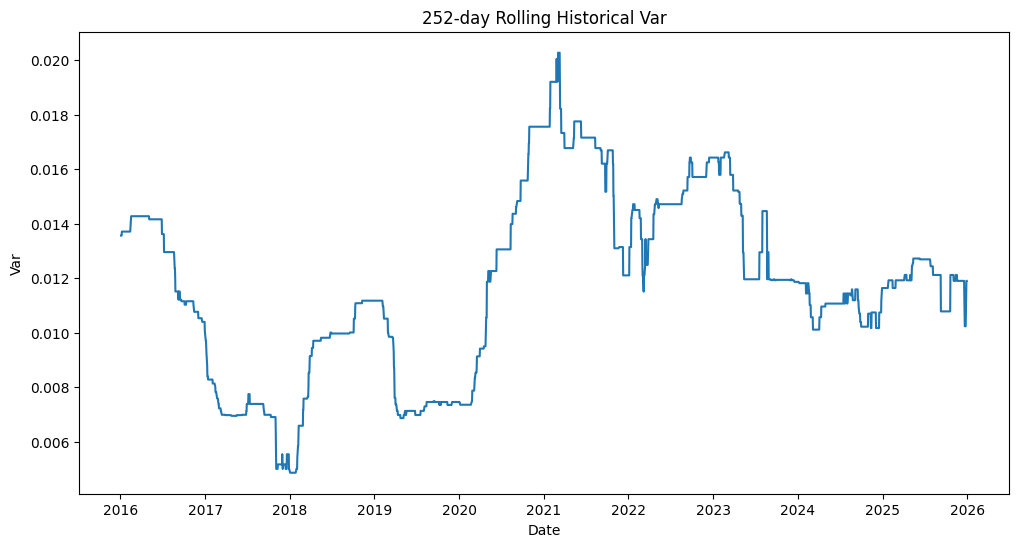

In [7]:
es = risk.calculate_expected_shortfall(strategy_returns)
historical_var = risk.calculate_historical_var(strategy_returns)
parametric_var = risk.calculate_parametric_var(strategy_returns)

rolling_var = risk.calculate_rolling_var(strategy_returns)

risk.plot_rolling_var(rolling_var)

controlled_returns = risk.apply_risk_control(strategy_returns,rolling_var)

6. backtesting

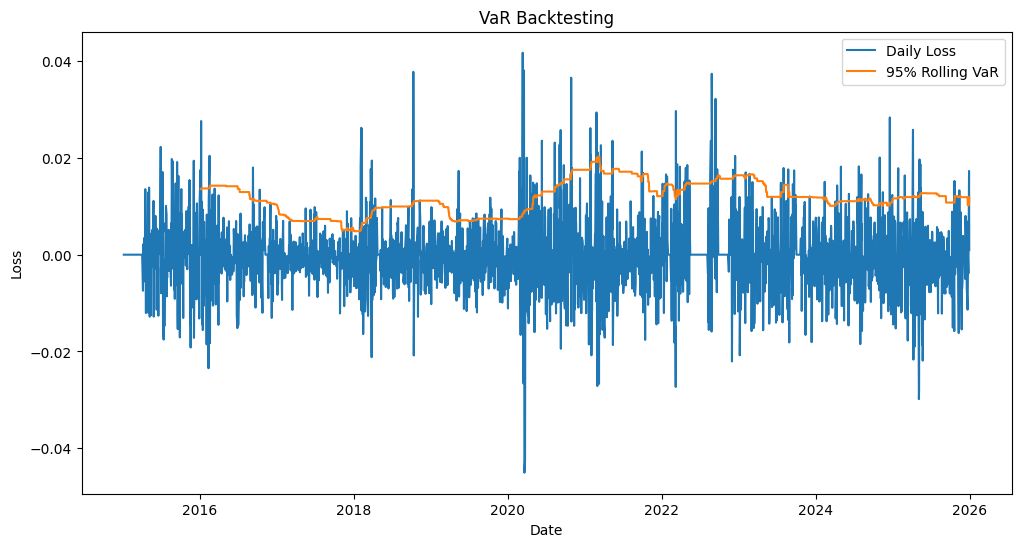

{'Breach Count': np.int64(135), 'Breach Rate': np.float64(0.04884225759768451)}
Date
2020-03-12    0.041766
2020-03-18    0.038092
2018-10-10    0.037817
2022-08-26    0.037417
2020-10-28    0.036600
Name: Momentum Strategy, dtype: float64


In [8]:
breaches = bt.calculate_var_breaches(strategy_returns,rolling_var)
summary = bt.backtest_summary(breaches)
bt.plot_var_backtest(strategy_returns,rolling_var)
largest = bt.largest_breaches(strategy_returns,rolling_var)
print(summary)
print(largest)

7. stress testing

In [ ]:
scenarios = risk.stress_scenarios()
current_weights = weights.iloc[-1]
stress_result = risk.run_stress_test(
    current_weights,
    tickers,
    scenarios
)

print(stress_result)

Equity Selloff    -0.044312
Rates Shock       -0.010267
Crisis Risk-Off   -0.048090
Inflation Shock   -0.014045
Name: Portfolio Return, dtype: float64


8. Benchmark comparison

,Momentum Strategy,Static Benchmark
Total Return,1.909749,1.822324
Annualized Return,0.102277,0.099215
Annualized Volatility,0.114922,0.099236
Sharpe Ratio,0.905045,1.003021
Maximum Drawdown,-0.292371,-0.244106
Win Ratio,0.513025,0.553907


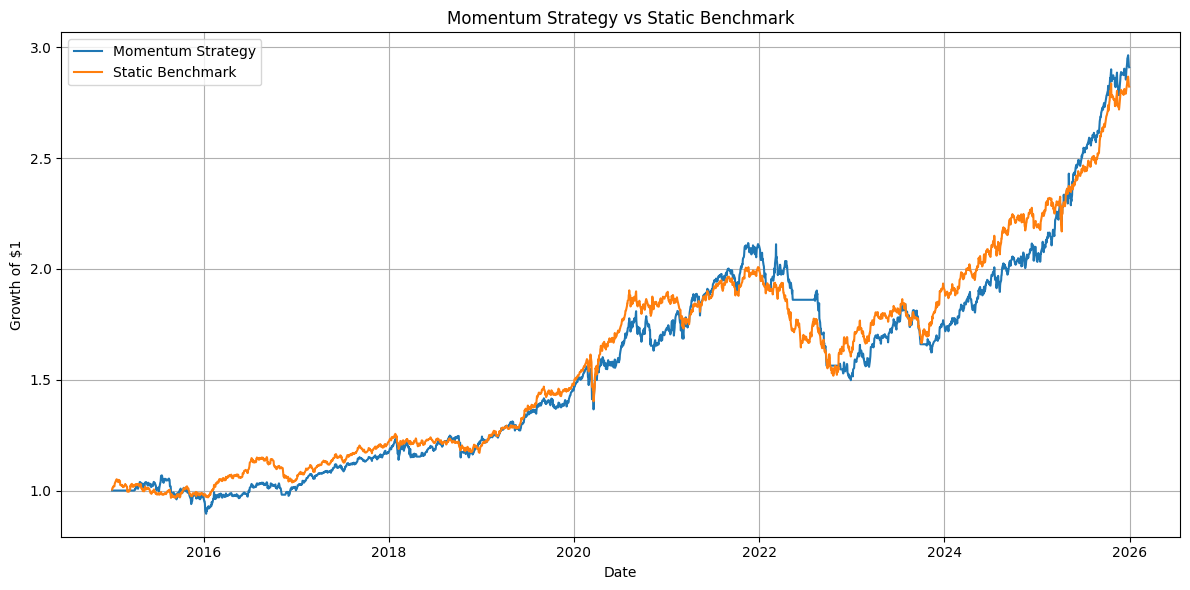

In [10]:
import pandas as pd

# Static benchmark allocation: SPY 1/6, QQQ 1/6, TLT 1/3, GLD 1/3
benchmark_returns = port.calculate_benchmark_returns(returns)

# Use exactly the same dates for a fair strategy-versus-benchmark comparison.
comparison_returns = pd.concat(
    [
        strategy_returns.rename("Momentum Strategy"),
        benchmark_returns.rename("Static Benchmark"),
    ],
    axis=1,
    join="inner",
).dropna()

strategy_comparison_returns = comparison_returns["Momentum Strategy"]
benchmark_comparison_returns = comparison_returns["Static Benchmark"]

comparison_figure = port.plot_strategy_vs_benchmark(
    strategy_comparison_returns,
    benchmark_comparison_returns,
)

strategy_metrics = perf.calculate_performance_metrics(
    strategy_comparison_returns
)
benchmark_metrics = perf.calculate_performance_metrics(
    benchmark_comparison_returns
)
comparison = port.create_performance_comparison(
    strategy_metrics,
    benchmark_metrics,
)

comparison